<a href="https://colab.research.google.com/github/NamithaRStat/Parallel_Project_NLP/blob/main/NLP_Parallel_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Libraries

In [16]:
!pip install wordcloud

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud
from collections import Counter

import string
# for stopword management
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import re

# for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import PorterStemmer, WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


# Reading data

In [3]:
# calling amazon,  yelp and imdb text data filepaths
filepath_amazon = "/content/drive/MyDrive/ICT_AIML/data/amazon_cells_labelled.txt"
filepath_yelp = "/content/drive/MyDrive/ICT_AIML/data/yelp_labelled.txt"
filepath_imdb = "/content/drive/MyDrive/ICT_AIML/data/imdb_labelled.txt"

In [9]:
# converting the text data into data frames with splitting text and target columns
df_amazon = pd.read_csv(
    filepath_amazon,
    sep="\t",
    header=None,
    names=["text", "target"]
)

df_yelp = pd.read_csv(
    filepath_yelp,
    sep="\t",
    header=None,
    names=["text", "target"])

df_imdb = pd.read_csv(
    filepath_imdb,
    sep="\t",
    header=None,
    names=["text", "target"])

# combining the dataframes into a single dataframe
df_sentimental = pd.concat(
    [df_amazon, df_yelp, df_imdb],
    axis=0,
    ignore_index=True
)


,text,target
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


# EDA

In [10]:
df_sentimental.head()

,text,target
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [11]:
df_sentimental.info()
# the target column is encoded and the column text is object data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2748 non-null   object
 1   target  2748 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 43.1+ KB


In [13]:
df_sentimental.isna().sum()
# no missing values in any columns

,0
text,0
target,0


In [15]:
df_sentimental['target'].value_counts()
# both positive sentiment and negative sentiment classes are having similiar number of observations. Hence it is a balanced data

,count
target,
1,1386
0,1362


## Creating the word cloud

In [18]:
# combining all reviews into a single text
text = " ".join(df_sentimental["text"])

In [19]:
# creating the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

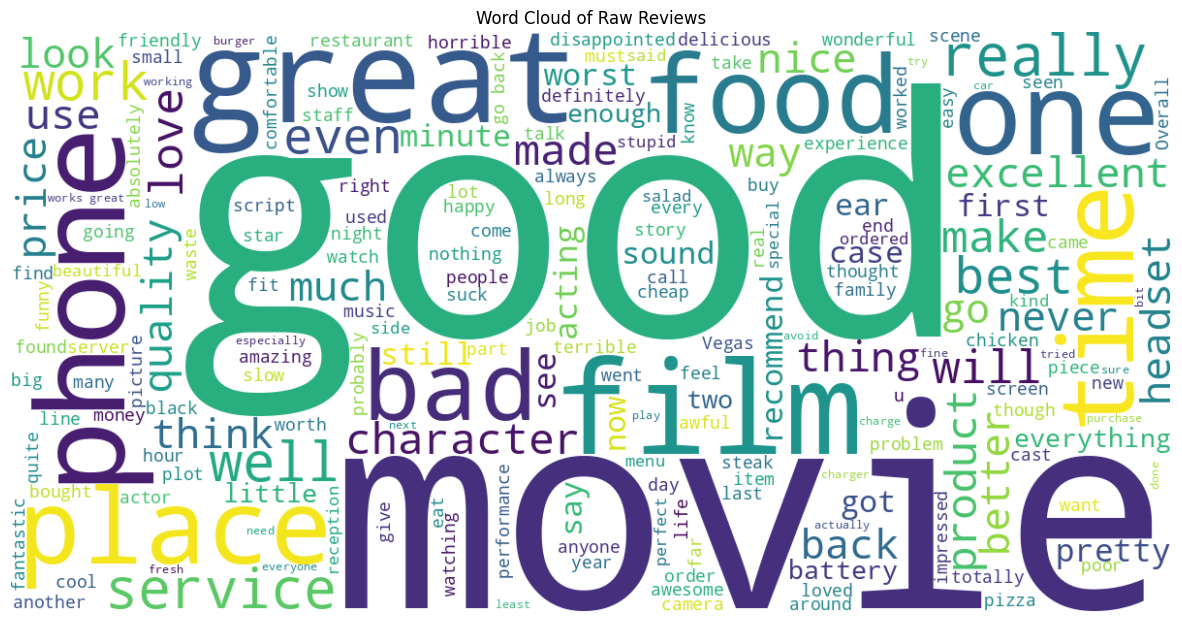

In [20]:
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Raw Reviews")
plt.show()

Most frequent word is good. Words related to entertainment such as food, film, movie, phone, time is also frequently appeared.

## Finding the frquency of the words

In [22]:
# Split the text into words
words = text.split()

# Count the frequency of each word
word_counts = Counter(words)

# Display the 20 most frequent words
word_counts.most_common(20)

# before preprocessing commonly occuring words are majorly stopwords.

[('the', 1474),
 ('and', 1095),
 ('I', 851),
 ('a', 846),
 ('is', 732),
 ('to', 652),
 ('of', 608),
 ('was', 558),
 ('The', 459),
 ('this', 442),
 ('it', 396),
 ('in', 373),
 ('for', 315),
 ('that', 275),
 ('with', 263),
 ('not', 256),
 ('my', 212),
 ('on', 203),
 ('very', 194),
 ('have', 177)]

# Preprocessing

## Removing the punctuation

In [28]:

# displaying the predefined punctuations in string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [32]:

# replacing all punctuations with empty string
df_sentimental['text'] = df_sentimental['text'].str.replace(
        f'[{string.punctuation}]',
        '',
        regex=True
        # for finding anything matches the given pattern in string.punctuation.
    )

## Lowercasing

In [34]:
df_sentimental['text'] = df_sentimental['text'].str.lower()

## Managing stopwords

In [37]:
stop_words = set(stopwords.words('english'))
stopword_count = df_sentimental['text'].apply(
        lambda text: sum(word in stop_words for word in text.split())
    ).sum()
print(f"Total stop words: {stopword_count}")

# there are 16,735 stopwords

Total stop words: 16735


In [38]:
# Removing stop words to eliminate commonly occurring words that contribute little to distinguishing the sentiment of a review.
df_sentimental["text"] = df_sentimental["text"].apply(
    lambda text: " ".join(
        word for word in text.split() if word not in stop_words
    )
)

In [39]:
# verifying the stopwords are removed
stopword_count = df_sentimental["text"].apply(
    lambda text: sum(word in stop_words for word in text.split())
).sum()

print(f"Total stop words after removal: {stopword_count}")

# after removing stop words, remaining number of stopwords is 0

Total stop words after removal: 0


## Managing the numbers

In [42]:
count = df_sentimental['text'].str.contains(r'\d', regex=True).sum()
print(f"Total number of numbers in the text column: {count}")

text: 224


In [43]:
# inspecting the texts with numbers
df_sentimental[df_sentimental["text"].str.contains(r"\d", regex=True)].head(20)

,text,target
3,tied charger conversations lasting 45 minutesm...,0
12,two seperated mere 5 ft started notice excessi...,0
26,ive owned phone 7 months say best mobile phone...,1
35,need least 3 mins get phone book time first tu...,0
38,case great works fine 680,1
40,great camera thats 2mp pics nice clear great p...,1
57,even dropped phone stream submerged 15 seconds...,1
58,happy 510 complaints one regarding sound quali...,1
65,one big drawback mp3 player buttons phones fro...,0
69,device great several situations1,1


Numerical values were retained during preprocessing because they can contribute to sentiment classification by representing ratings or other sentiment-bearing information.

## Managing special characters

In [44]:
# counting the special characters
print(df_sentimental['text'].str.contains(r'[^A-Za-z0-9\s]', regex=True).sum())

15


In [45]:
# inspecting the texts with special characters
df_sentimental[df_sentimental["text"].str.contains(r'[^A-Za-z0-9\s]', regex=True)].head(20)

,text,target
1150,fiancé came middle day greeted seated right away,1
1598,really enjoyed crema café expanded even told f...,1
1823,crêpe delicate thin moist,1
1915,thing wasnt crazy guacamole dont like puréed,0
2018,practically perfect  true masterpiece sea fau...,1
2019,structure film easily tightly constructed hist...,0
2121,ill even say  torture,0
2226,show made americans stupid full hatred clichés...,0
2271,cheap cheerless heist movie poor characterisat...,0
2297,forgot casting superb trond fausa aurvåg perfe...,1


In [47]:
# Removing special characters as they do not contribute to the sentiment of the text.
df_sentimental["text"] = df_sentimental["text"].apply(
    lambda text: re.sub(r"[^A-Za-z0-9\s]", "", text)
)

## Managing HTML tags

In [52]:
# Counting the number of texts containing HTML tags
html_count = df_sentimental['text'].str.contains(r'<.*?>', regex=True).sum()

print(f"{html_count} texts contain HTML tags.")

0 texts contain HTML tags.


## Tokenisation

In [53]:
df_sentimental['text_tokenized'] = df_sentimental['text'].str.split()

In [54]:
df_sentimental.head()

,text,target,text_tokenized
0,way plug us unless go converter,0,"[way, plug, us, unless, go, converter]"
1,good case excellent value,1,"[good, case, excellent, value]"
2,great jawbone,1,"[great, jawbone]"
3,tied charger conversations lasting 45 minutesm...,0,"[tied, charger, conversations, lasting, 45, mi..."
4,mic great,1,"[mic, great]"


## Lemmatization

Lemmatization was chosen because it converts words to their dictionary (base) forms, making them more suitable for Word2Vec vectorization.

In [56]:
# creating an object
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the tokenized text
df_sentimental['tokens_lemmatized'] = df_sentimental['text_tokenized'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

# Create a function that takes one input called tokens
#Considering tokens in each row; for each word in tokens, lemmatize it using the lemmatizer.